In [28]:
# Requirements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
plt.rcParams['pdf.fonttype'] = 42

In [29]:
metadata = pd.read_csv("/Users/madisoncreach/Prediction_Project/pheno_data/Mural_2022/giac080_supplemental_files/SupplementalDataFileS3_PhenotypeMetaData_Locations_Altered.csv")
pheno_reduced = pd.read_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/full_phenos_reduced.csv")

In [30]:
columns_df2 = pheno_reduced.columns
metadata_filtered = metadata[metadata["TraitID"].isin(columns_df2)]

In [31]:
print(metadata)

                TraitID            SourcePaper  \
0    LastJuvenileLeaf_A     Hirsch et al. 2014   
1            Anthesis_A     Hirsch et al. 2014   
2             Silking_A     Hirsch et al. 2014   
3            SMVAUPDC_B  Gustafson et al. 2018   
4             SMV7DAI_B  Gustafson et al. 2018   
..                  ...                    ...   
176         AnthesisDAP                    NaN   
177          SilkingDAP                    NaN   
178       dry_g_per_ear                    NaN   
179    TestWeight.lb.bu                    NaN   
180            Moisture                    NaN   

                             TraitNameInOriginalSource PhenotypeGroup  \
0    Last leaf with epicuticular wax/Last Juvenile ...     Vegetative   
1                   Growing Degree Days to Pollen Shed  FloweringTime   
2                          Growing Degree Days to Silk  FloweringTime   
3                Area under the disease progress curve        Disease   
4             Percent Incidence of

In [32]:
print(columns_df2)

Index(['GeneID', 'SilkingGDD_L', 'AnthesisGDD_L', 'ASIGDD_L', 'Silking_L',
       'Anthesis1_L', 'ASI_L', 'PlantHeight_L', 'EarHeight_L', 'PH-EH_L',
       ...
       'ExpLeaves3Avg', 'FlagHeightAvg', 'TotalHeightAvg', 'Weight.g',
       'TotalLeafNumberAvg', 'LargestLeafLengthAvg', 'AnthesisDAP',
       'SilkingDAP', 'dry_g_per_ear', 'TestWeight.lb.bu'],
      dtype='object', length=130)


In [33]:
print(metadata_filtered)

                  TraitID            SourcePaper  \
0      LastJuvenileLeaf_A     Hirsch et al. 2014   
1              Anthesis_A     Hirsch et al. 2014   
2               Silking_A     Hirsch et al. 2014   
4               SMV7DAI_B  Gustafson et al. 2018   
10        TasselLength1_C       Gage et al. 2018   
..                    ...                    ...   
174  LargestLeafLengthAvg                    NaN   
176           AnthesisDAP                    NaN   
177            SilkingDAP                    NaN   
178         dry_g_per_ear                    NaN   
179      TestWeight.lb.bu                    NaN   

                             TraitNameInOriginalSource PhenotypeGroup  \
0    Last leaf with epicuticular wax/Last Juvenile ...     Vegetative   
1                   Growing Degree Days to Pollen Shed  FloweringTime   
2                          Growing Degree Days to Silk  FloweringTime   
4             Percent Incidence of SCMV Symptoms_7 DAI        Disease   
10        

In [34]:
city_colors = {
    "East Lansing, Michigan": "#377eb8",
    "Lincoln_NE": "#e41a1c",
    "Ithaca_NY": "#4daf4a",
    "Ames_IA": "#984ea3",
    "Arlington_WI": "#ff7f00",
    "Arlington_WI; WestMadison_WI": "#ff7f00",
    "Maricopa_AZ": "#f781bf",
    "San Diego_CA": "#a65628",
    "Multiple_Fields": "#ffff33",
    "Unknown": "#c4c7c2",
}

In [35]:
grouped = metadata_filtered.groupby(["PhenotypeGroup", "FieldExperimentLocations"]).size().reset_index(name="Count")

In [36]:
# Count traits per PhenotypeGroup and Location
phenotype_order = ["Vegetative", "Inflorescence", "FloweringTime", "Agronomic", "Cellular/Biochemical", "SeedComposition", "Disease", "Root", "Other"]
grouped["PhenotypeGroup"] = pd.Categorical(grouped["PhenotypeGroup"], categories=phenotype_order, ordered=True)
grouped = grouped.sort_values("PhenotypeGroup")

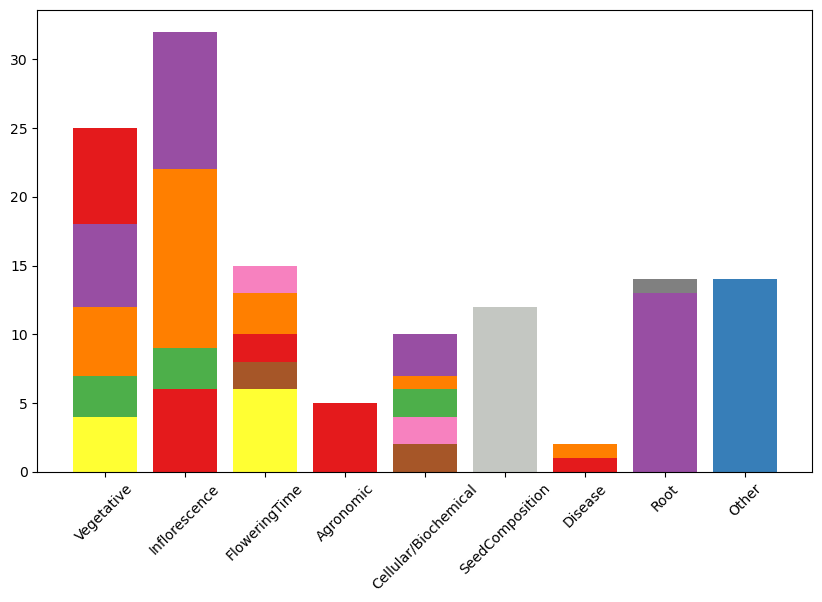

In [37]:
phenotype_groups = grouped["PhenotypeGroup"].unique()

fig, ax = plt.subplots(figsize=(10,6))

for pg in phenotype_order:  # loop in your desired order
    subset = grouped[grouped["PhenotypeGroup"] == pg]
    bottom = 0
    for _, row in subset.iterrows():
        ax.bar(pg, row["Count"], bottom=bottom, color=city_colors.get(row["FieldExperimentLocations"], "gray"))
        bottom += row["Count"]

# Set ticks in the same order
ax.set_xticks(range(len(phenotype_order)))
ax.set_xticklabels(phenotype_order, rotation=45)
plt.savefig("/Users/madisoncreach/Prediction_Project/Pheno_Groups.pdf")
